In [1]:
import gzip
import json
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import beta
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.metrics import log_loss, auc, roc_auc_score, roc_curve
from sklearn.metrics import RocCurveDisplay
from xgboost import XGBClassifier

from bayesbet.base.models import BayesianMLPClassifier
from bayesbet.base.preprocessing import FeatureSelector
from bayesbet.nhl.preprocessing import ShotFeatures

In [2]:
train_seasons = [
    20142015,
    20152016,
    20162017,
    20172018,
    20182019,
    20192020,
    20202021,
    20212022,
    20222023,
]
test_seasons = [20232024]
train_shots = pd.concat(
    [
        pd.read_parquet(f"../experiments/data/preprocessed/{season}/shots.parquet")
        for season in train_seasons
    ],
    ignore_index=True,
)
test_shots = pd.concat(
    [
        pd.read_parquet(f"../experiments/data/preprocessed/{season}/shots.parquet")
        for season in test_seasons
    ],
    ignore_index=True,
)

In [3]:
train_shots.head(10)

,shot_is_home_team,home_team_defending_side,shot_type,shot_x,shot_y,goal_x,goal_y,last_event,last_event_x,last_event_y,...,opposing_skaters,current_skaters,time_since_even_strength,empty_net,goal,play_number,player_id,venue_name,venue_location,game_id
0,False,right,wrist,61,29,89,0,faceoff,1,1,...,5,5,0,False,False,2,8471976,Air Canada Centre,Toronto,2014020001
1,True,right,backhand,54,-29,89,0,blocked-shot,62,27,...,5,5,0,False,False,4,8475098,Air Canada Centre,Toronto,2014020001
2,True,right,wrist,40,-32,89,0,blocked-shot,42,9,...,5,5,0,False,False,9,8471392,Air Canada Centre,Toronto,2014020001
3,True,right,snap,72,8,89,0,shot-on-goal,40,-32,...,5,5,0,False,False,10,8470207,Air Canada Centre,Toronto,2014020001
4,False,right,wrist,37,30,89,0,faceoff,-69,20,...,5,5,0,False,False,17,8476470,Air Canada Centre,Toronto,2014020001
5,True,right,snap,66,-1,89,0,missed-shot,-37,-30,...,5,5,0,False,False,18,8473463,Air Canada Centre,Toronto,2014020001
6,True,right,wrist,57,34,89,0,giveaway,66,19,...,5,5,0,False,False,25,8475180,Air Canada Centre,Toronto,2014020001
7,True,right,wrist,60,13,89,0,hit,24,32,...,5,5,0,False,False,29,8475172,Air Canada Centre,Toronto,2014020001
8,False,right,wrist,68,-5,89,0,blocked-shot,-71,0,...,5,5,0,False,False,36,8469707,Air Canada Centre,Toronto,2014020001
9,False,right,wrist,82,-15,89,0,giveaway,51,34,...,5,5,0,False,True,38,8474157,Air Canada Centre,Toronto,2014020001


In [4]:
train_shots.shape

(1000944, 22)

In [5]:
train_shots.columns

Index(['shot_is_home_team', 'home_team_defending_side', 'shot_type', 'shot_x',
       'shot_y', 'goal_x', 'goal_y', 'last_event', 'last_event_x',
       'last_event_y', 'time_since_last_event', 'last_event_same_team',
       'opposing_skaters', 'current_skaters', 'time_since_even_strength',
       'empty_net', 'goal', 'play_number', 'player_id', 'venue_name',
       'venue_location', 'game_id'],
      dtype='object')

In [6]:
float_cols = [
    "shot_x",
    "shot_y",
    "shot_distance",
    "shot_angle",
    "last_event_x",
    "last_event_y",
    "last_event_distance",
    "last_event_angle",
    "time_since_last_event",
    "opposing_skaters",
    "current_skaters",
    "time_since_even_strength",
    "rebound_angle",
]
categorical_cols = ["shot_type", "last_event", "is_rebound"]

X_train = train_shots.drop(columns=["goal"])
y_train = train_shots["goal"]

X_test = test_shots.drop(columns=["goal"])
y_test = test_shots["goal"]

In [7]:
step_size = 1e-2

preprocessor = ColumnTransformer(
    transformers=[
        ("scale", RobustScaler(), float_cols),
        (
            "onehot",
            OneHotEncoder(drop="if_binary", handle_unknown="infrequent_if_exist"),
            categorical_cols,
        ),
    ]
)

classifier = BayesianMLPClassifier(
    hidden_layer_sizes=(15, 15, 15),
    num_warmup=5000,
    num_samples=70000,
    step_size=step_size,
    show_progress=True,
)

# classifier = MLPClassifier(
#     hidden_layer_sizes=(20, 20, 20, 20), max_iter=1000, alpha=1e-4
# )

# classifier = XGBClassifier(
#     n_estimators=1000, learning_rate=0.1, max_depth=1, random_state=42
# )

pipe = Pipeline(
    [
        ("features", ShotFeatures()),
        ("selector", FeatureSelector(float_cols, categorical_cols)),
        ("preprocess", preprocessor),
        ("classifier", classifier),
    ]
)

In [8]:
scoring = ["neg_log_loss", "roc_auc"]
scores = cross_validate(
    pipe, X_train, y_train, cv=5, scoring=scoring, return_train_score=True
)
scores

100%|██████████| 75000/75000 [00:40<00:00, 1857.49it/s]
/Users/everett/.local/share/virtualenvs/model-WfP3nPDb/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


{'fit_time': array([39.56141996, 38.53149629, 41.37319827, 42.73009396, 41.6160121 ]),
 'score_time': array([0.26970315, 0.18204975, 0.18215275, 0.19079399, 0.28692794]),
 'test_neg_log_loss': array([-0.22347115, -0.22450101, -0.22459163, -0.22338588, -0.22816335]),
 'train_neg_log_loss': array([-0.2241328 , -0.22437686, -0.22389901, -0.22451208, -0.22442395]),
 'test_roc_auc': array([0.75794918, 0.75459503, 0.75334981, 0.75862774, 0.73724437]),
 'train_roc_auc': array([0.75529986, 0.75477691, 0.75573114, 0.75299876, 0.75276083])}

In [9]:
-np.mean(scores["train_neg_log_loss"])

0.22426893839214596

In [10]:
np.mean(scores["train_roc_auc"])

0.7543135010056634

In [11]:
-np.mean(scores["test_neg_log_loss"])

0.22482260420809674

In [12]:
np.mean(scores["test_roc_auc"])

0.7523532242684696

In [13]:
pipe.fit(X_train, y_train)

100%|██████████| 75000/75000 [00:37<00:00, 1979.23it/s]


Pipeline(steps=[('features', ShotFeatures()),
                ('selector',
                 FeatureSelector(categorical_cols=['shot_type', 'last_event',
                                                   'is_rebound'],
                                 float_cols=['shot_x', 'shot_y',
                                             'shot_distance', 'shot_angle',
                                             'last_event_x', 'last_event_y',
                                             'last_event_distance',
                                             'last_event_angle',
                                             'time_since_last_event',
                                             'opposing_skaters',
                                             'current_skaters',
                                             'time_since_even_strength',
                                             're...
                                                   'time_since_last_event',
                                                   'opposing_skaters',
                                                   'current_skaters',
                                                   'time_since_even_strength',
                                                   'rebound_angle']),
                                                 ('onehot',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='infrequent_if_exist'),
                                                  ['shot_type', 'last_event',
                                                   'is_rebound'])])),
                ('classifier',
                 BayesianMLPClassifier(hidden_layer_sizes=(15, 15, 15),
                                       num_samples=70000, num_warmup=5000,
                                       show_progress=True))])

In [14]:
y_pred_proba = pipe.predict_proba(X_train)
log_loss(y_train, y_pred_proba)

0.22397390503508263

In [15]:
roc_auc_score(y_train, y_pred_proba[:, 1])

0.7554618374117619

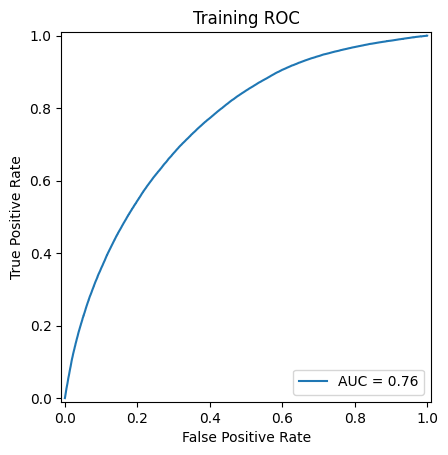

In [16]:
y_pred = pipe.predict_proba(X_train)[:, 1]
fpr, tpr, thresholds = roc_curve(y_train, y_pred)
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
display.plot()
plt.title("Training ROC")
plt.show()

In [17]:
y_pred_proba = pipe.predict_proba(X_test)
log_loss(y_test, y_pred_proba)

0.23060533443400977

In [18]:
roc_auc_score(y_test, y_pred_proba[:, 1])

0.7456101242399014

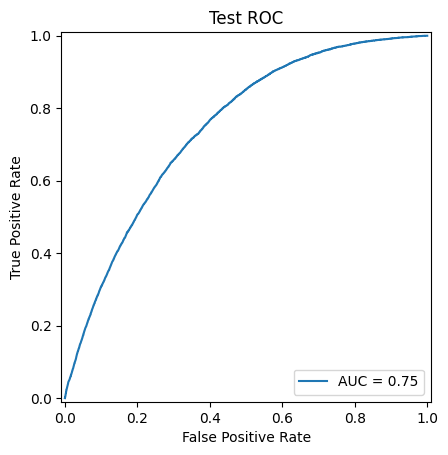

In [19]:
y_pred = pipe.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
display.plot()
plt.title("Test ROC")
plt.show()

In [20]:
from scipy.interpolate import griddata

y_train_prob = pipe.predict_proba(X_train)

[x, y] = np.round(np.meshgrid(np.linspace(0, 100, 100), np.linspace(-42.5, 42.5, 85)))
expected_goals = griddata(
    (train_shots["shot_x"], train_shots["shot_y"]),
    y_train_prob[:, 1],
    (x, y),
    method="cubic",
    fill_value=0,
)
expected_goals[expected_goals < 0] = 0

In [21]:
def plot_rink(ax, plot_half=False, board_radius=28, alpha=1):
    def add_arc(center, theta1, theta2):
        ax.add_artist(
            mpl.patches.Arc(
                center,
                board_radius * 2,
                board_radius * 2,
                theta1=theta1,
                theta2=theta2,
                edgecolor="black",
                lw=2,
                zorder=0,
                alpha=alpha,
            )
        )

    # Corner Boards
    corners = [
        ((100 - board_radius, (85 / 2) - board_radius), 0, 89),
        ((-100 + board_radius, (85 / 2) - board_radius), 90, 180),
        ((-100 + board_radius, -(85 / 2) + board_radius), 180, 270),
        ((100 - board_radius, -(85 / 2) + board_radius), 270, 360),
    ]
    for center, theta1, theta2 in corners:
        add_arc(center, theta1, theta2)

    # Plot Boards
    boards = [
        ([-100 + board_radius, 100 - board_radius], [-42.5, -42.5]),
        ([-100 + board_radius, 100 - board_radius], [42.5, 42.5]),
        ([-100, -100], [-42.5 + board_radius, 42.5 - board_radius]),
        ([100, 100], [-42.5 + board_radius, 42.5 - board_radius]),
    ]
    for x, y in boards:
        ax.plot(x, y, linewidth=2, color="black", zorder=0, alpha=alpha)

    # Goal Lines
    for x in [-89, 89]:
        ax.plot(
            [x, x],
            [-42.5 + 4.7, 42.5 - 4.7],
            linewidth=3,
            color="firebrick",
            zorder=0,
            alpha=alpha,
        )

    # Center Line and FaceOff Dot
    ax.plot(
        [0, 0], [-42.5, 42.5], linewidth=3, color="firebrick", zorder=0, alpha=alpha
    )
    ax.plot(0, 0, markersize=6, color="mediumblue", marker="o", zorder=0, alpha=alpha)

    # Center Circle
    ax.add_artist(
        mpl.patches.Circle(
            (0, 0),
            radius=33 / 2,
            facecolor="none",
            edgecolor="mediumblue",
            linewidth=3,
            zorder=0,
            alpha=alpha,
        )
    )

    # Zone Faceoff Dots and Circles
    for x, y in [(69, 22), (69, -22), (-69, 22), (-69, -22)]:
        ax.plot(
            x, y, markersize=6, color="firebrick", marker="o", zorder=0, alpha=alpha
        )
        ax.add_artist(
            mpl.patches.Circle(
                (x, y),
                radius=15,
                facecolor="none",
                edgecolor="firebrick",
                linewidth=3,
                zorder=0,
                alpha=alpha,
            )
        )

    # Neutral Zone Faceoff Dots
    for x, y in [(22, 22), (22, -22), (-22, 22), (-22, -22)]:
        ax.plot(
            x, y, markersize=6, color="firebrick", marker="o", zorder=0, alpha=alpha
        )

    # Blue Lines
    for x in [-25, 25]:
        ax.plot(
            [x, x],
            [-42.5, 42.5],
            linewidth=3,
            color="mediumblue",
            zorder=0,
            alpha=alpha,
        )

    # Goalie Crease and Goal
    for x in [-89, 89]:
        ax.add_artist(
            mpl.patches.Arc(
                (x, 0),
                6,
                6,
                theta1=90 if x > 0 else 270,
                theta2=270 if x > 0 else 90,
                facecolor="mediumblue",
                edgecolor="firebrick",
                lw=2,
                zorder=0,
                alpha=alpha,
            )
        )
        ax.add_artist(
            mpl.patches.Rectangle(
                (x if x > 0 else x - 2, -2),
                2,
                4,
                lw=2,
                color="firebrick",
                fill=False,
                zorder=0,
                alpha=alpha,
            )
        )

    # Set axis limits and remove spines
    ax.set_xlim((-0.5, 100.5) if plot_half else (-101, 101))
    ax.set_ylim(-43, 43)
    for spine in ax.spines.values():
        spine.set_visible(False)

In [22]:
def plot_expected_goals(expected_goals):
    fig, ax = plt.subplots(1, 1, figsize=(11, 12), facecolor="w", edgecolor="k")
    expected_goal_heatmap = ax.imshow(
        expected_goals, alpha=0.5, cmap="jet", extent=[0, 100, -42.5, 42.5]
    )
    plot_rink(ax, plot_half=True, board_radius=25, alpha=0.9)
    plt.axis("off")
    fig.colorbar(expected_goal_heatmap, orientation="horizontal", pad=0.05)
    plt.title("Expected Goals")

    return fig

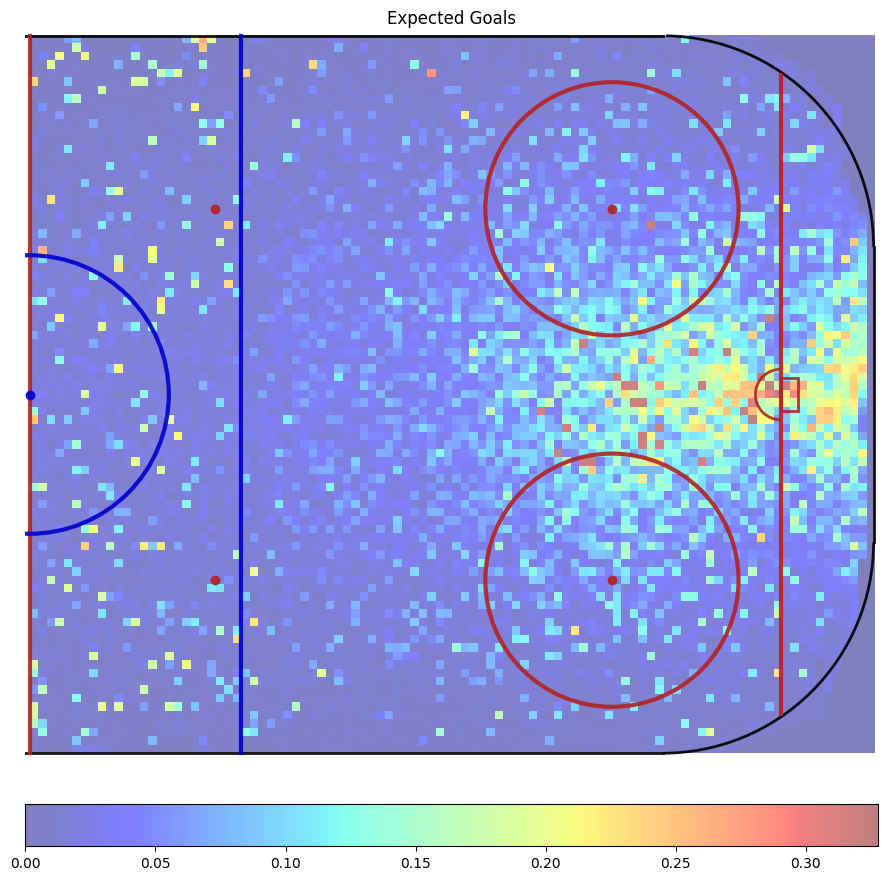

In [23]:
fig = plot_expected_goals(expected_goals)

In [24]:
players_json = {}
seasons = [
    20142015,
    20152016,
    20162017,
    20172018,
    20182019,
    20192020,
    20202021,
    20212022,
    20222023,
    20232024,
]
for season in seasons:
    with gzip.open(f"../experiments/data/raw/{season}/players.json.gz", "rb") as f:
        season_players_json = json.loads(f.read().decode("utf-8"))
        players_json.update(season_players_json)

players_json = {int(key): value for key, value in players_json.items()}

In [25]:
# Get the shot data after the first features transformer has been applied
expected_goals_by_player = train_shots.copy()
expected_goals_by_player = pipe.named_steps["features"].transform(expected_goals_by_player)

expected_goals_by_player["expected_goal"] = pipe.predict_proba(
    train_shots.drop(
        columns=[
            "goal",
            "home_team_defending_side",
            "play_number",
            "player_id",
            "game_id",
        ]
    )
)[:, 1]
expected_goals_by_player["player_name"] = expected_goals_by_player["player_id"].map(players_json)

In [26]:
best_players = expected_goals_by_player.groupby(["player_id", "player_name"]).agg(
    {"expected_goal": ["mean", "median", "count"]}
)
best_players = best_players[best_players[("expected_goal", "count")] > 500]

In [27]:
best_players.sort_values(("expected_goal", "mean"), ascending=False).head(50)

expected_goal                
                                         mean    median count
player_id player_name                                        
8479977   Kailer Yamamoto            0.109027  0.099242   540
8474038   Paul Byron                 0.108590  0.103256   769
8478462   Nicolas Roy                0.104247  0.095721   594
8478402   Connor McDavid             0.103522  0.094245  2766
8475786   Zach Hyman                 0.103338  0.098323  1860
8478010   Brayden Point              0.101758  0.094141  1979
8471669   Paul Stastny               0.100835  0.094373  1686
8476460   Mark Scheifele             0.100769  0.093836  2219
8478047   Michael Bunting            0.100268  0.094953   581
8475855   Jesper Fast                0.099501  0.093587  1035
8477497   Sean Monahan               0.099454  0.092494  2075
8473533   Jordan Staal               0.099054  0.093715  1801
8476881   Tomas Hertl                0.098914  0.092959  2213
8470610   Zach Parise                0.098885  0.091925  2186
8470794   Joe Pavelski               0.098402  0.091372  2959
8478233   Andrew Mangiapane          0.098185  0.090823   945
8477989   Christian Dvorak           0.098022  0.091578   947
8477934   Leon Draisaitl             0.097897  0.090650  2557
8482093   Seth Jarvis                0.097818  0.088638   528
8475314   Anders Lee                 0.097794  0.095328  2364
8475098   Tyler Bozak                0.097674  0.087755  1306
8477404   Jake Guentzel              0.097457  0.089917  1923
8475754   Brock Nelson               0.097325  0.087904  2236
8475166   John Tavares               0.097300  0.089441  3314
8474641   Adam Henrique              0.096404  0.090771  1688
8473546   Michael Grabner            0.096251  0.083493   909
8473412   Bryan Little               0.095801  0.086228   958
8480002   Nico Hischier              0.095787  0.088545  1306
8476905   Chandler Stephenson        0.095729  0.086391   782
8470621   Corey Perry                0.095686  0.089693  2183
8479314   Matthew Tkachuk            0.095480  0.090111  2203
8468208   Joel Ward                  0.095465  0.087341   729
8477964   Ivan Barbashev             0.095423  0.087086   806
8478445   Mathew Barzal              0.095335  0.081975  1454
8478449   Roope Hintz                0.095003  0.087680  1203
8478427   Sebastian Aho              0.094904  0.083991  2323
8475170   Brayden Schenn             0.094894  0.088795  2127
8473573   Artem Anisimov             0.094851  0.088796  1028
8475913   Mark Stone                 0.094636  0.085312  1995
8475820   Joonas Donskoi             0.094535  0.079943  1117
8479542   Brandon Hagel              0.094206  0.089446   601
8473604   Jonathan Toews             0.094175  0.082252  1972
8476480   Vladislav Namestnikov      0.094043  0.086595  1289
8477500   Bo Horvat                  0.093824  0.086432  2133
8470740   Lee Stempniak              0.093806  0.081610   618
8467514   Pavel Datsyuk              0.093519  0.077871   530
8482116   Tim Stützle                0.093516  0.082370   717
8474190   Wayne Simmonds             0.093516  0.088913  1766
8476456   Jonathan Huberdeau         0.093479  0.077743  2105
8476918   Jimmy Vesey                0.093405  0.082410  1129

In [45]:
def expected_goals_per_game(expected_goals_frequency_per_game, player_posterior_mean):
    return np.sum(expected_goals_frequency_per_game * player_posterior_mean)


def plot_player_expected_goals(player_name, prior_strength=1, num_bins=20):
    selected_player_expected_goals = expected_goals_by_player[
        expected_goals_by_player["player_name"] == player_name
    ]
    X = selected_player_expected_goals["expected_goal"].values.reshape(-1)
    y = selected_player_expected_goals["goal"].values

    # Calculate number of games played and shots taken
    num_games = selected_player_expected_goals["game_id"].nunique()
    total_shots = selected_player_expected_goals.shape[0]

    # Get the maximum expected_goal value rounded up to the nearest 0.1
    max_expected_goal = expected_goals_by_player["expected_goal"].max().round(1)

    bin_edges = np.linspace(0, max_expected_goal, num_bins + 1)
    digitized = np.digitize(X, bin_edges)

    # Calculate bin centers
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    alphas = np.zeros(num_bins)
    betas = np.zeros(num_bins)

    for i in range(1, num_bins + 1):
        bin_goals = y[digitized == i]
        bin_expected_goals = X[digitized == i]

        if len(bin_expected_goals) > 0:
            # Set priors based on the bin center
            bin_center = bin_centers[i - 1]
            alpha_prior = prior_strength * bin_center
            beta_prior = prior_strength * (1 - bin_center)

            alphas[i - 1] = alpha_prior + np.sum(bin_goals)
            betas[i - 1] = beta_prior + len(bin_goals) - np.sum(bin_goals)
        else:
            # If the bin is empty, use the bin center as the estimate
            bin_center = bin_centers[i - 1]
            alphas[i - 1] = prior_strength * bin_center
            betas[i - 1] = prior_strength * (1 - bin_center)

    mean_probs = alphas / (alphas + betas)
    ci_lower = beta.ppf(0.025, alphas, betas)
    ci_upper = beta.ppf(0.975, alphas, betas)

    # Create a new figure with 3 subplots
    fig, (ax0, ax1, ax2) = plt.subplots(
        3, 1, figsize=(10, 9), sharex=True, gridspec_kw={"height_ratios": [1, 3, 2]}
    )

    # Plot the distribution of shots
    expected_goal_frequencies, _, _ = ax0.hist(
        X,
        bins=bin_edges,
        density=False,
        weights=np.ones_like(y) / num_games,
        alpha=0.7,
        color="steelblue",
    )
    ax0.set_ylabel("Frequency")
    ax0.set_title("Expected Goals Distribution of Shots Per Game")

    # Plot expected_goal vs actual goals, posterior mean, and bayesian CI
    ax1.scatter(X, y, color="dimgrey", alpha=0.25, label="Observed Shot")
    ax1.axline(
        xy1=(0, 0),
        xy2=(max_expected_goal, max_expected_goal),
        color="grey",
        linestyle="--",
        label="Expected Goal Value of Shot",
    )
    ax1.errorbar(
        bin_centers,
        mean_probs,
        yerr=[mean_probs - ci_lower, ci_upper - mean_probs],
        fmt="o",
        color="steelblue",
        ecolor="steelblue",
        capsize=5,
        label="Player Posterior Mean (95% CI)",
    )
    ax1.set_ylabel("Goal Probability")
    ax1.set_xlabel("Expected Goals")
    ax1.set_title("Player Performance vs Expected Goal Value of Shots")
    ax1.legend()

    # Calculate relative performance
    relative_mean = (mean_probs - bin_centers) / bin_centers * 100
    relative_ci_lower = (ci_lower - bin_centers) / bin_centers * 100
    relative_ci_upper = (ci_upper - bin_centers) / bin_centers * 100

    # Plot relative performance
    ax2.scatter(bin_centers, relative_mean, color="steelblue")
    ax2.errorbar(
        bin_centers,
        relative_mean,
        yerr=[relative_mean - relative_ci_lower, relative_ci_upper - relative_mean],
        fmt="o",
        color="steelblue",
        ecolor="steelblue",
        capsize=5,
    )
    ax2.axhline(y=0, color="grey", linestyle="--")
    ax2.set_ylabel("Relative Performance (%)")
    ax2.set_xlabel("Expected Goals")
    ax2.set_title("Relative Performance to Expected Goal Value")

    plt.suptitle(player_name)
    plt.tight_layout()
    plt.show()

    print(f"Player: {player_name}")
    print(f"Games Played: {num_games}")
    print(f"Total Shots: {total_shots}")
    print(f"Expected Goals per Game: {expected_goals_per_game(expected_goal_frequencies, mean_probs):.4f}")
    print(f"Mean expected_goal: {np.mean(X):.4f}")
    print(f"Median expected_goal: {np.median(X):.4f}")
    print(f"Goal Percentage: {np.mean(y):.4f}")

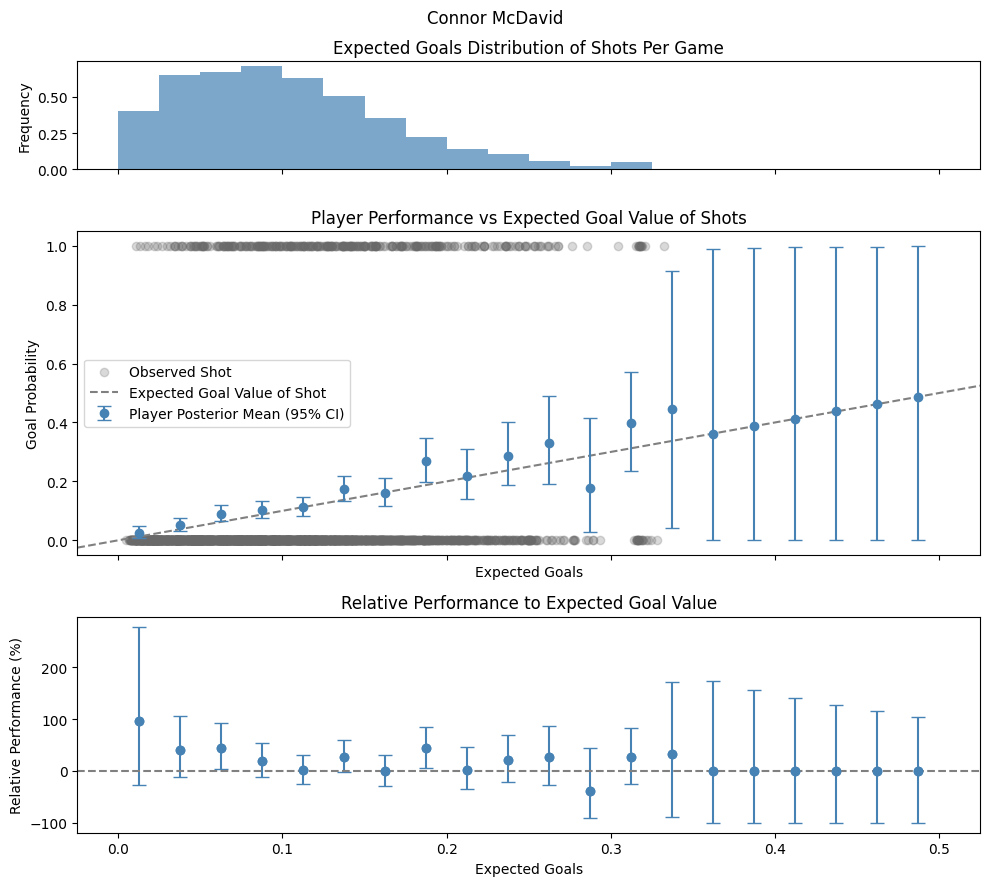

Player: Connor McDavid
Games Played: 613
Total Shots: 2766
Expected Goals per Game: 0.5605
Mean expected_goal: 0.1035
Median expected_goal: 0.0942
Goal Percentage: 0.1244


In [46]:
plot_player_expected_goals("Connor McDavid")

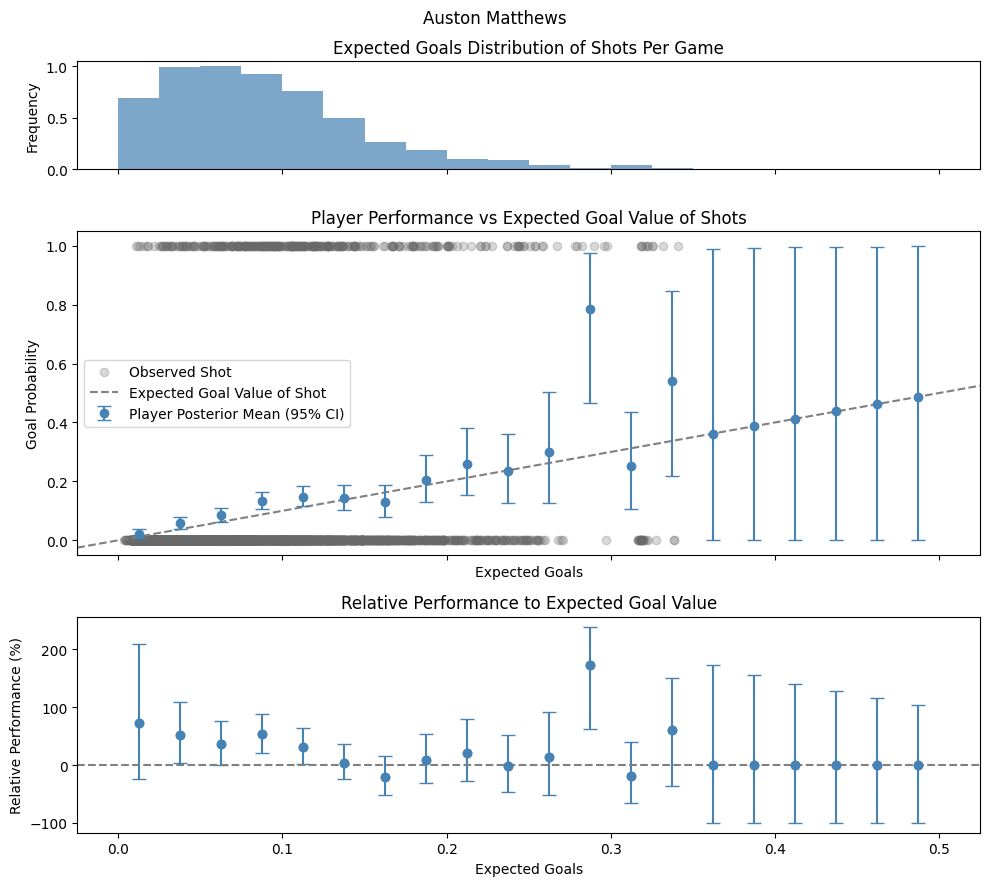

Player: Auston Matthews
Games Played: 530
Total Shots: 2983
Expected Goals per Game: 0.6248
Mean expected_goal: 0.0883
Median expected_goal: 0.0779
Goal Percentage: 0.1113


In [47]:
plot_player_expected_goals("Auston Matthews")

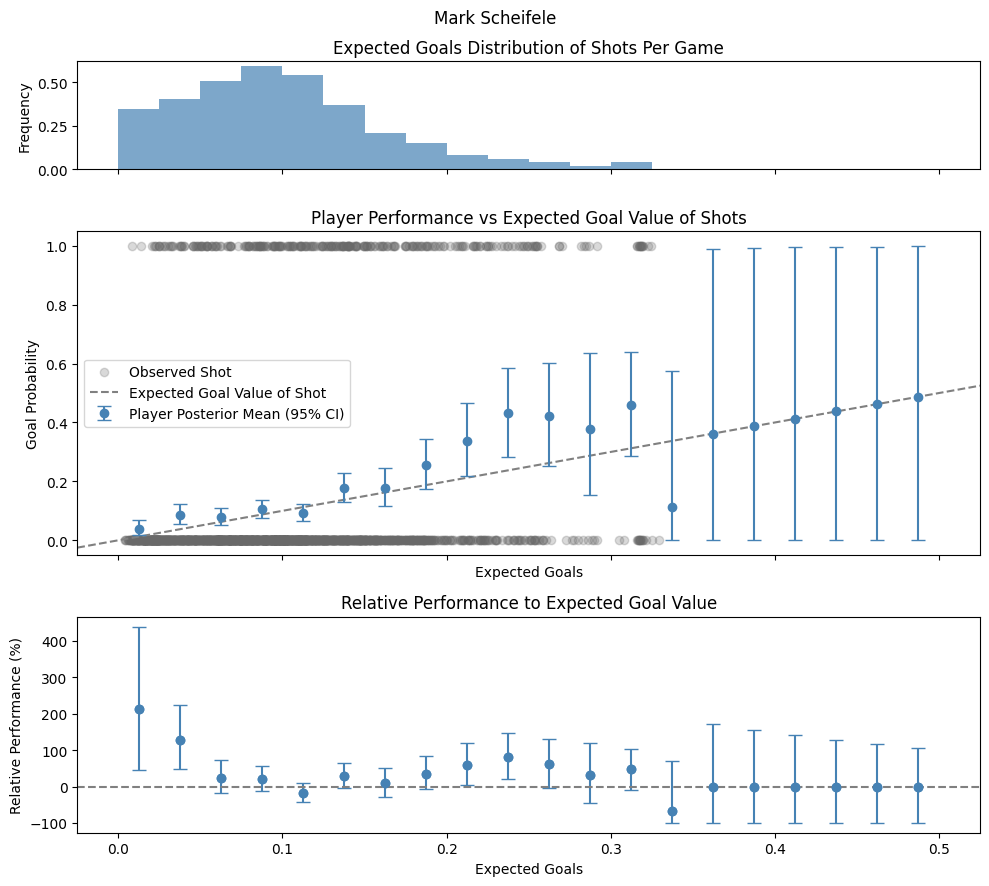

Player: Mark Scheifele
Games Played: 660
Total Shots: 2219
Expected Goals per Game: 0.4368
Mean expected_goal: 0.1008
Median expected_goal: 0.0938
Goal Percentage: 0.1302


In [48]:
plot_player_expected_goals("Mark Scheifele")

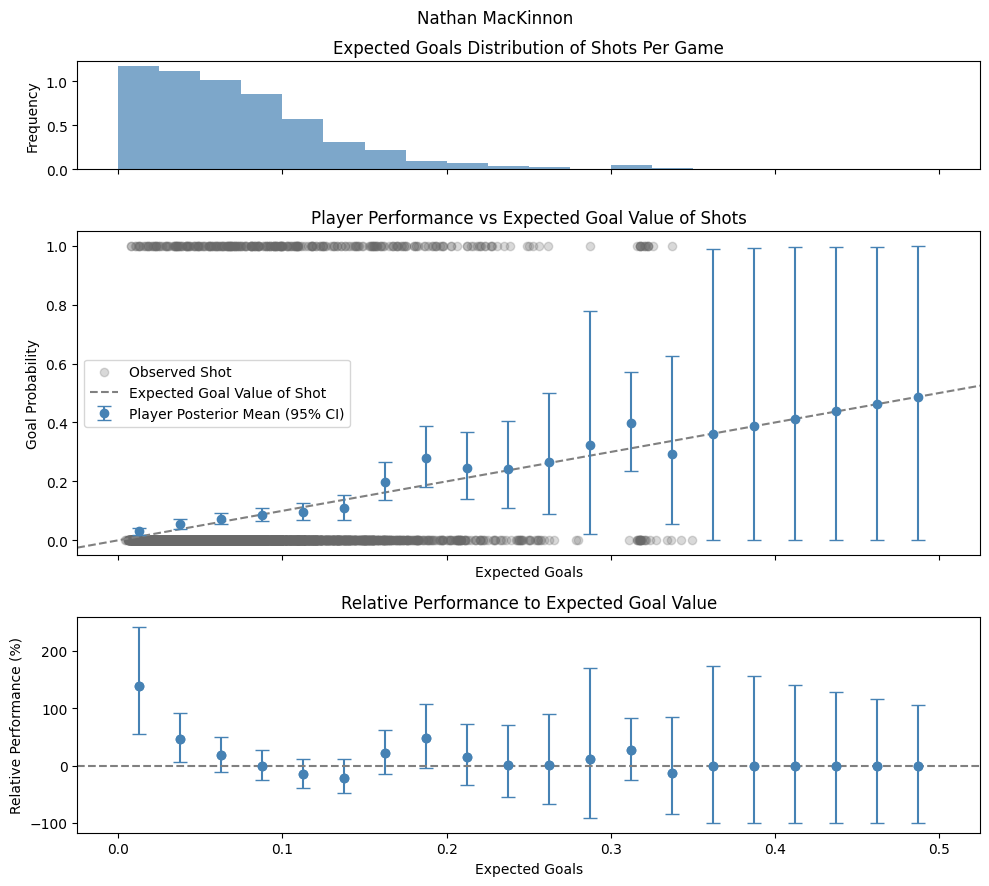

Player: Nathan MacKinnon
Games Played: 686
Total Shots: 3802
Expected Goals per Game: 0.4588
Mean expected_goal: 0.0734
Median expected_goal: 0.0620
Goal Percentage: 0.0829


In [49]:
plot_player_expected_goals("Nathan MacKinnon")

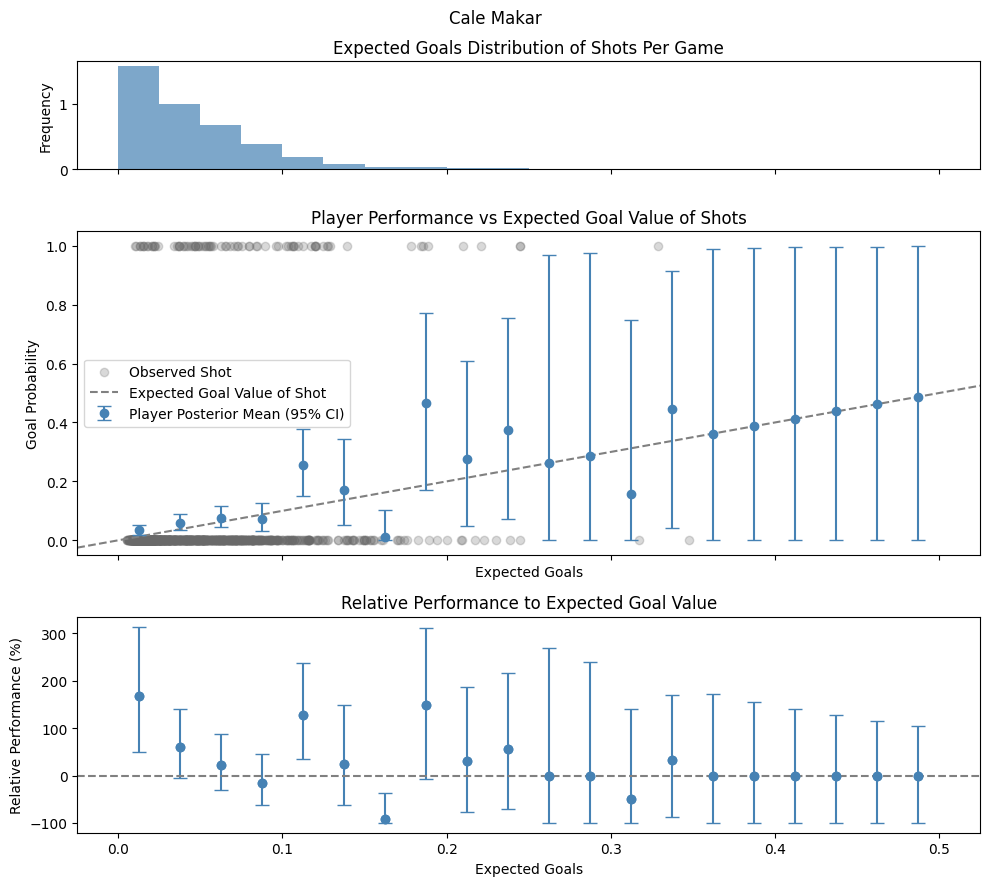

Player: Cale Makar
Games Played: 286
Total Shots: 1149
Expected Goals per Game: 0.2850
Mean expected_goal: 0.0480
Median expected_goal: 0.0348
Goal Percentage: 0.0714


In [50]:
plot_player_expected_goals("Cale Makar")

In [51]:
goal_tended_shots = expected_goals_by_player[expected_goals_by_player["empty_net"] == False].reset_index(
    drop=True
)
goal_tended_shots["goal"] = goal_tended_shots["goal"].astype(int)

In [36]:
empty_net_shots = expected_goals_by_player[expected_goals_by_player["empty_net"] == False].reset_index(
    drop=True
)
empty_net_shots["goal"] = empty_net_shots["goal"].astype(int)

In [37]:
def plot_expected_goals_by_feature(shots_with_expected_goals, x_axis_feature="shot_distance", hue_feature="opposing_skaters"):
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=shots_with_expected_goals,
        x=x_axis_feature,
        y="expected_goal",
        hue=hue_feature,
        palette="viridis",
        alpha=0.25,
        legend="full"
    )

    x_axis_feature_title = x_axis_feature.replace("_", " ").title()
    hue_feature_title = hue_feature.replace("_", " ").title()

    plt.title(f"Expected Goal vs {x_axis_feature_title}")
    plt.xlabel(x_axis_feature_title)
    plt.ylabel(hue_feature_title)
    plt.legend(title=hue_feature_title, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

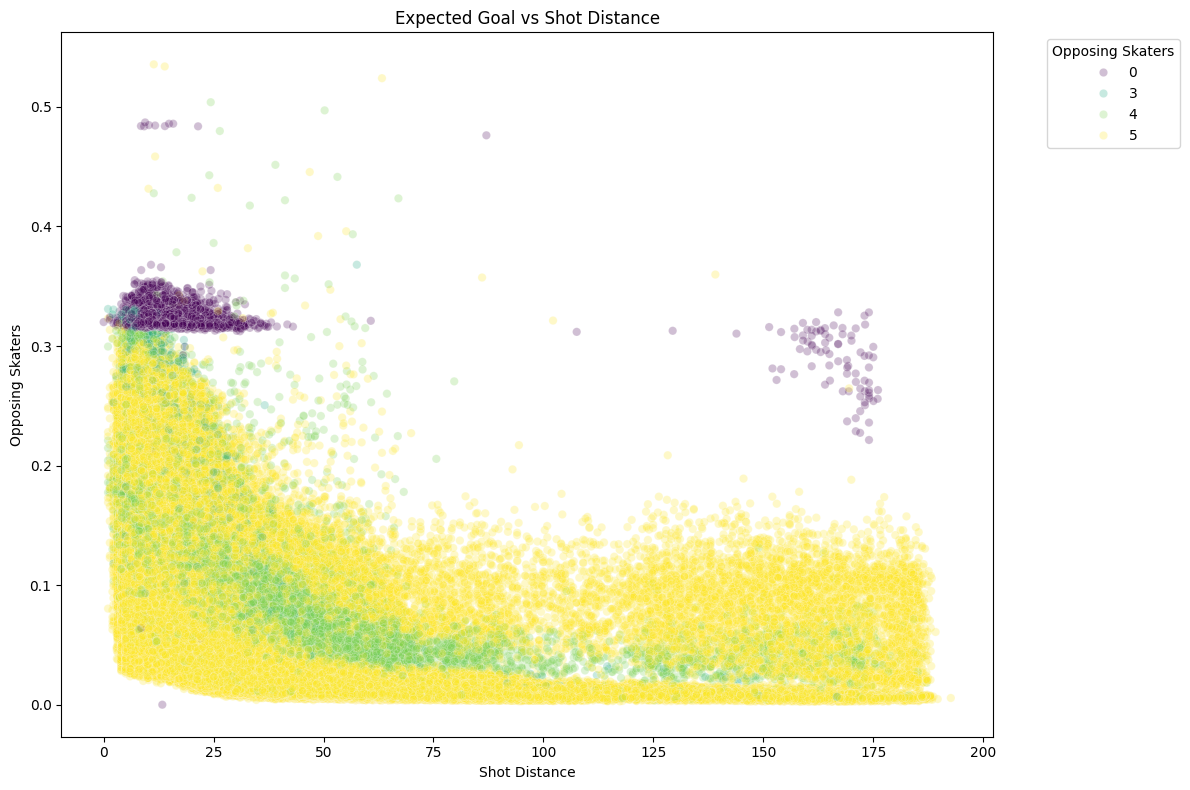

In [38]:
plot_expected_goals_by_feature(goal_tended_shots, x_axis_feature="shot_distance", hue_feature="opposing_skaters")

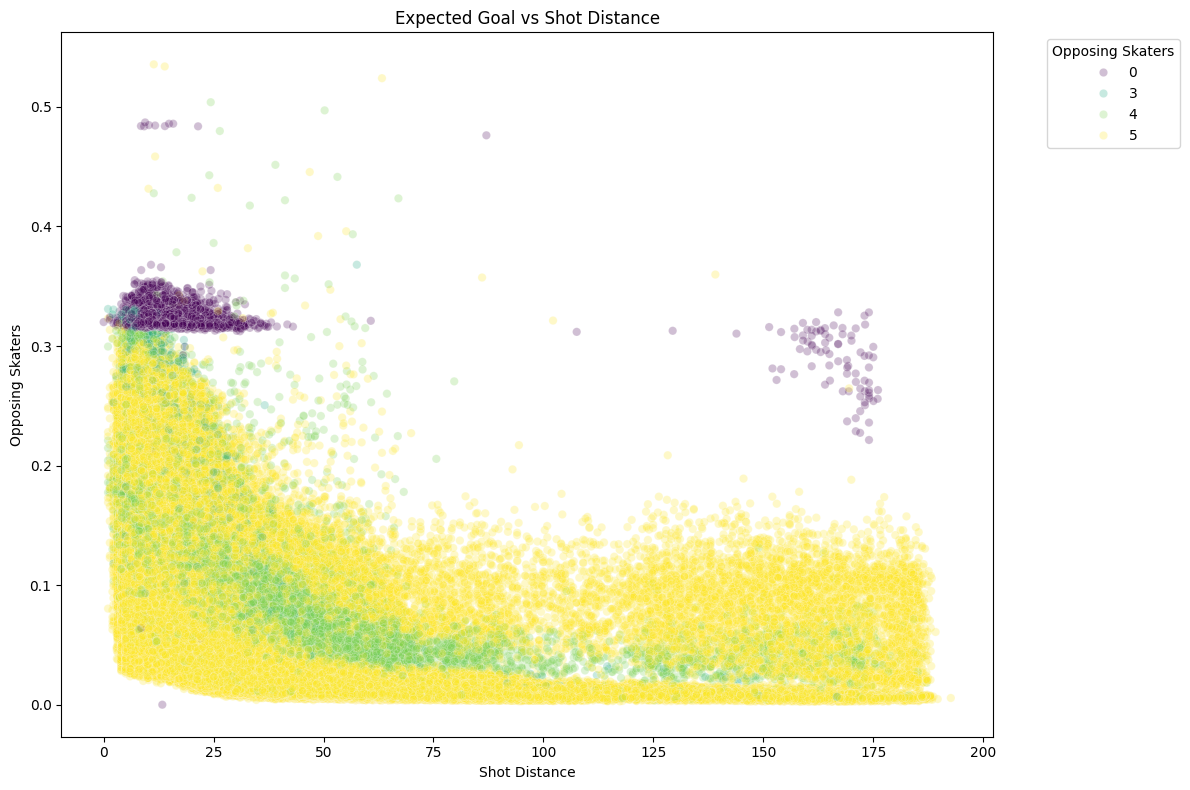

In [39]:
plot_expected_goals_by_feature(goal_tended_shots, x_axis_feature="shot_distance", hue_feature="opposing_skaters")

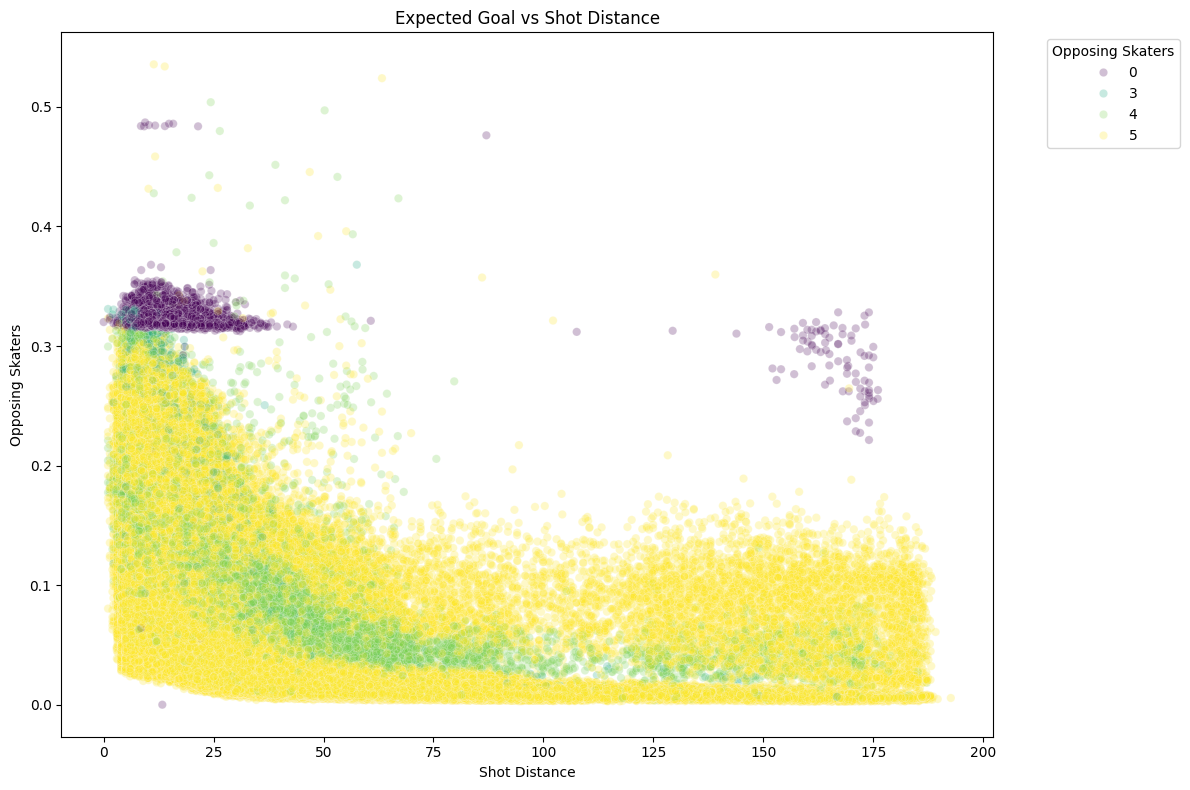

In [40]:
plot_expected_goals_by_feature(empty_net_shots, x_axis_feature="shot_distance", hue_feature="opposing_skaters")

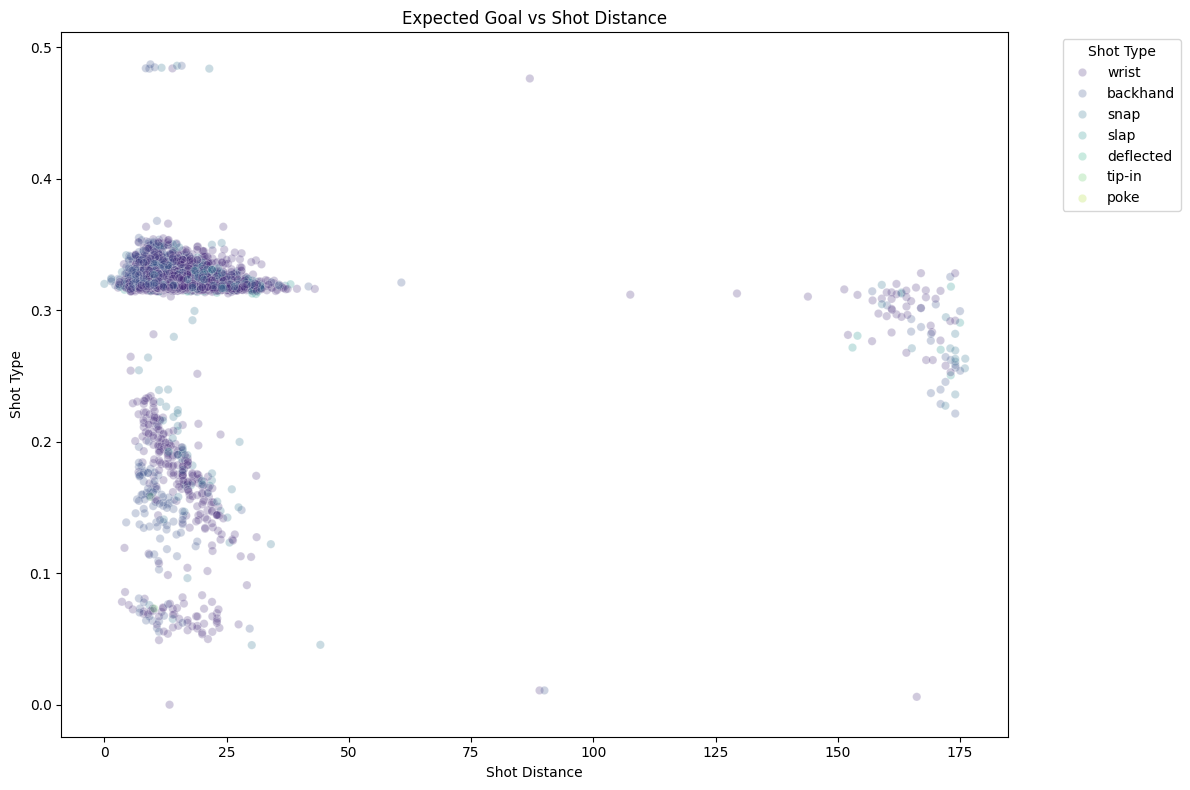

In [41]:
shoot_out_shots = expected_goals_by_player[
    (
        (expected_goals_by_player["current_skaters"] == 1)
        & (expected_goals_by_player["opposing_skaters"] == 0)
    )
].reset_index(drop=True)
plot_expected_goals_by_feature(shoot_out_shots, x_axis_feature="shot_distance", hue_feature="shot_type")